# Goal

The goal of this notebook is to create a light version of [ecoagent.tech](https://ecoagent.tech/welcome). We will create ecoinvent matching using LLM's and integrate it directly in our brightway workflow. Actually, the workflow in this notebook came first through using brightway, which then was the idea behind ecoagent.

We will look at an example of using LLM models in your LCA workflow using brightway, instead. More specifically, automated database matching using local or commercial LLM's.

# Architecture

So to enable the database matching, we will use the so called retrieval augmented generation (RAG). As the name suggests, the response *generation* of an LLM is *augmented* through *retrieval*.

It has been quite popular, since the arrival of LLM models. It is frequently used in custom chatbots to retrieve custom data or [grounding](https://ai.google.dev/gemini-api/docs/google-search) the LLM response on a web search. So that LLM's don't rely solely on the training data.

So we are going to use the architecture in figure below. Often the embeddings are stored in a vector or postgres database. For our use case, we can just simply store it in memory. Since we are working only with ecoinvent cut-off 3.11 database. If the database becomes large, then a vector database makes a lot more sense.

-----------------------
To explain the architecture a bit:
1. Query comes in (e.g. gasoline combustion)
2. Query is translated into an embedding e.g. 'gasoline combustion' would be converted into [1, 5, 0...]
3. Most similar items from the database is retrieved using closest vector distances
4. The retrieved items are sent to LLM, which then answers accordingly

Now you may ask, why do I need a vector search?
I can just do a normal 'string search' on my database and the LLM can respond appriopriately. You are absolutely right! (as claude would say)

The vector search just works better to find the relevant entries, where the string search would fail. for example: 
- with typos
- words like 'sulfur' and 'sulphur'
- synonmys 'petrol' and 'gasoline'

I would guess that the new [ecoQuery semantic search](https://ecoinvent.org/blog/ecoquery-semantic-search-update/) also uses a similar approach but I don't know for sure.

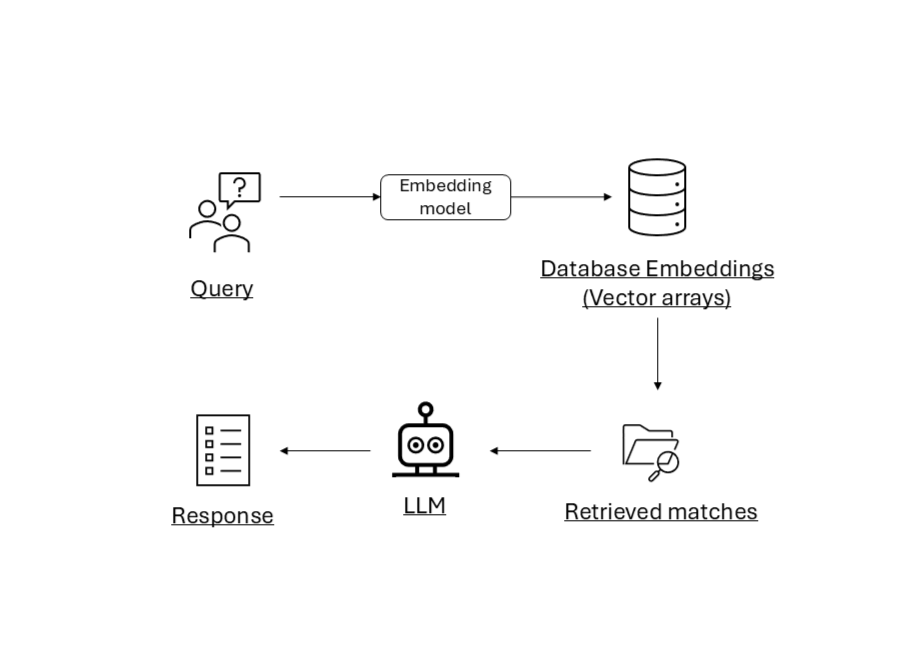

# Initialize

In [1]:
import bw2data as bd

In [2]:
bd.projects.set_current(name='play_7_2_26')

In [3]:
biosphere311 = bd.Database('ecoinvent-3.11-biosphere')
ecoinvent311 = bd.Database('ecoinvent-3.11-cutoff')

# Embedding database

First, we will prepare database embeddings. So converting the relevant database entries into vector arrays [1, 5, 0...]

## Ecoinvent data prep

Since we are only aiming to find the matches from the database, we would want to embed only the activity name, reference product and product information. One tip is that you need to give just the right amount of information. I'd say this is more trial and error, depending on the use case. Too little or too much data -> less relevant results.

In ecoinvent, there are multiple geographical variations of an activity, with the same activity name, reference product and product information. So we skip the duplicates ;) 

In [5]:
import time
from tqdm.notebook import tqdm

start_time = time.perf_counter()

unique_entries_set = {
    f"Name: {act['name']} | Reference Product: {act['reference product']} | Info: {act['product_information']}"
    for act in tqdm(ecoinvent311, desc="Extracting activities")
}

# 2. Convert to a list for the embedding model
eco_311_list = list(unique_entries_set)

elapsed = time.perf_counter() - start_time
print(f"Prepared {len(eco_311_list)} unique entries in {elapsed:.2f} seconds.")

Extracting activities:   0%|          | 0/25412 [00:00<?, ?it/s]

Prepared 11465 unique entries in 7.87 seconds.


-----------------------------------
Note that the no. of activities in ecoinvent 3.11 is 25,412. But we have 11,465 unique entries. So the unique entries worked.
Let's have a look inside:

In [8]:
eco_311_list[0]

'Name: market for container ship | Reference Product: container ship | Info: This product is an infrastructure that is used in the service of transportation. The container ship has a lifetime of 25 years, with load capacity of 43,000 tonnes and an average transport distance 166,298 km/year.'

## Create embeddings

We create vector embeddings for the database. AKA semantic search.

Embeddings carry the semantic meaning of a text. E.g. it can be inferred that tomato and cucumber are similar to each other than to a cat.

First we load an embedding model. Many choices exist for this, plus many are free and can be run locally.

In [4]:
from sentence_transformers import SentenceTransformer, util, InputExample, losses
#Load the model(here we use minilm)
loaded_model = SentenceTransformer("Snowflake/snowflake-arctic-embed-xs")

C:\Users\Hemant\miniconda3\envs\play_new\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [10]:
embeddings = loaded_model.encode(eco_311_list, show_progress_bar=True)

Batches:   0%|          | 0/359 [00:00<?, ?it/s]

-------------------
It took me around 20mins. let's see how scary our vectors are. so this is what the entry 'market for container ship' looks like

In [13]:
embeddings[0]

array([ 0.08043148,  0.045546  ,  0.06801022, -0.00384044, -0.03910623,
       -0.02724992,  0.05648264, -0.05883003,  0.01090836,  0.00594886,
        0.01851501,  0.05475444,  0.04619392,  0.00912473,  0.03158488,
       -0.02022663, -0.05378137, -0.00843075, -0.14238986,  0.00928881,
       -0.02592482, -0.00230933, -0.03552873,  0.01513673,  0.00849941,
       -0.02040656, -0.04135437, -0.04248996, -0.11127546, -0.16276447,
        0.01627206,  0.01508084, -0.13544384, -0.0067033 ,  0.00256832,
        0.04485701, -0.01553707,  0.01361911, -0.0057701 ,  0.02779595,
        0.0260497 , -0.01000325, -0.02552877,  0.02178801, -0.0514489 ,
       -0.02580681,  0.0244035 , -0.03996753,  0.02505313,  0.03903405,
       -0.04081894, -0.03376667, -0.03062608,  0.02997052,  0.00194656,
       -0.01284297,  0.00816695, -0.03376658,  0.06232566,  0.05184653,
        0.01623573,  0.01096934, -0.27316007,  0.01302144,  0.09188422,
       -0.07964334,  0.00320889, -0.02607295,  0.00302319, -0.02

-------------------
look how they massacred by boy (container ships)...

Anyway, we can also save the model but also the embeddings and the list so we don't have to spend next time to make them again.

In [14]:
import numpy as np
import pickle

# # Save the SentenceTransformer model to a local folder
# model.save("./arctic-embed-xs-local")

# Save the embeddings array efficiently
np.save("eco_311_embeddings.npy", embeddings)

# Save the original text list to map search indices back to strings
with open("eco_311_list.pkl", "wb") as f:
    pickle.dump(eco_311_list, f)

Also load them from disk to use next time ;)

In [5]:
from sentence_transformers import SentenceTransformer, util, InputExample, losses
import numpy as np
import pickle
# Load everything from disk
loaded_embeddings = np.load("eco_311_embeddings.npy")
with open("eco_311_list.pkl", "rb") as f:
    loaded_list = pickle.load(f)

## Search function

We create a search function based on the closest vector distances. In this function, following steps are followed:
1. convert the incoming query into a vector
2. find closest database entries in terms of vector distances
3. return those results

In [6]:
def search_db(query, top_k=10):
    """
    Encodes an incoming query and returns the closest matches based on cosine similarity.
    """
    # 1. Encode the incoming query
    query_embedding = loaded_model.encode(query)
    
    # 2. Calculate cosine similarity distances against all corpus embeddings
    # semantic_search returns a list of lists. We grab [0] since we only have one query.
    hits = util.semantic_search(query_embedding, loaded_embeddings, top_k=top_k)[0]
    
    # 3. Format and return the results
    results = []
    # print(f"Top {top_k} results for: '{query}'\n" + "-"*50)
    
    for hit in hits:
        idx = hit['corpus_id']
        score = hit['score']
        text = loaded_list[idx]
        
        # print(f"Score: {score:.4f} | Text: {text}")
        results.append({"text": text, "score": score})
        
    return results

------------------
so look, gasoline search also finds petroleum

In [7]:
search_db('gasoline')

[{'text': "Name: market for petroleum combustion, in drilling tests | Reference Product: petroleum combustion, in drilling tests | Info: This is delivering the service of 'petroleum combustion, in drilling tests'. It describes the use of petroleum as fossil fuel and includes the emission profile of combusting it.",
  'score': 0.765070915222168},
 {'text': "Name: petroleum combustion, in drilling tests | Reference Product: petroleum combustion, in drilling tests | Info: This is delivering the service of 'petroleum combustion, in drilling tests'. It describes the use of petroleum as fossil fuel and includes the emission profile of combusting it.",
  'score': 0.7635979056358337},
 {'text': 'Name: transport, pipeline, onshore, petroleum | Reference Product: transport, pipeline, onshore, petroleum | Info: This is delivering the service of transportation of 1 metric ton across the distance of 1 km. This service only considers the transportation of fuels, like petroleum, through onshore pipel

--------------------
sulfuric acid is also found, although not the first hit

In [8]:
search_db('sulphuric acid')

[{'text': "Name: alkyl sulfate (C12-14) production | Reference Product: alkyl sulfate (C12-14) | Info: Alkyl sulfates (C12-14) are nonionic surfactants. This type of product can either have no colour or have a colour that is in between yellow and brown. The main application of surfactants is in the production of cleaning products for both household application and personal care (Kosswig 2000). Alkyl sulphates are used usually in a concentration around 4%. The maximum concentration used is 20%. Alkyl sulphates can and are usually mixed with other surfactants (OECD 2007).\n This substances can either be produced in solid or liquid from and are usually sold with a purity range between 30 and 95% (OECD 2007). It is modelled as a pure substance. Modelling this substance in a solution requires the user to add the solvent of their choice in their models.\n \n Reference(s):\n Kosswig, K. 2000. Surfactants. In Ullmann's Encyclopedia of Industrial Chemistry, Electronic Release, Vol.35, pp.431-50

# Create your agent

Let's add LLM in the process, like we had originally planned. For this, i'll use [openrouter](https://openrouter.ai/) since it gives me good flexibility:
- to switch models between various providers (openai, mistral, gemini, etc.)
- select models which ensure no retention and no training
- enforce regional processing (e.g. only EU)

There is even a possibility to use a free models, but your data is probably going to be retained :)

Note this is not a paid endorsement, although if openrouter is listening...

## Local LLM: Ollama

----------------------------
It is also possible to use local llm models for this task. Unfortunately, I don't have good enough computer to be able to do that. If you have 4gb free disk space and 2-3 gb RAM, you could use **[ollama](https://pypi.org/project/ollama/)** in the workflow instead.

In [ ]:
import ollama

response = ollama.generate(
    model='phi-4-mini', 
    prompt='hello'
)
print(response['response'])

## Tool definitions

let's also add a web search api, just for fun. Duck duck go has a [free version](https://pypi.org/project/ddgs/), you can install using pip.

In [9]:
from ddgs import DDGS
def search_web(query: str, max_results: int = 5) -> str:
    """
    Searches the web using DuckDuckGo to retrieve real-time information.
    """
    try:
        with DDGS() as ddgs:
            # ddgs.text() returns a generator yielding dictionaries with 'title', 'href', and 'body'
            results = list(ddgs.text(query, max_results=max_results))
        return json.dumps(results)
    except Exception as e:
        return json.dumps({"error": f"Web search failed: {str(e)}"})

In [10]:
# Map function names to actual python functions
available_tools = {
    "search_db": search_db,
    "search_web": search_web
}

# Define the JSON schemas for the LLM to understand how to call these tools
tools_schema = [
    {
        "type": "function",
        "function": {
            "name": "search_db",
            "description": "Searches the internal semantic database for local knowledge and documents.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "The search query to match against the database"},
                    "top_k": {"type": "integer", "description": "Number of results to return", "default": 5}
                },
                "required": ["query"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "search_web",
            "description": "Searches the live internet via DuckDuckGo for current events, news, or external knowledge.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "The web search query"},
                    "max_results": {"type": "integer", "description": "Number of web results to return", "default": 5}
                },
                "required": ["query"]
            }
        }
    }
]

## Set up LLM API

If you are using openrouter, don't forget to get your api_key at [openrouter.ai](https://openrouter.ai/) and save the it in an .env file as *API_KEY='xxxxx'*

In [11]:
import os
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("API_KEY")

In [12]:
from openai import OpenAI
# Initialize the OpenAI client pointing to OpenRouter
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key
)

## Create agent

In [13]:
import json
def run_agent(user_prompt: str, max_iterations: int = 5):
    messages = [
        {
            "role": "system", 
            "content": "Your sole purpose is to search the database to find the most relevant queries. "
                       "You must use your tools to search the database. Synthesize the final answer based on the search results."
        },
        {"role": "user", "content": user_prompt}
    ]
    
    print(f"User: {user_prompt}\n" + "-"*50)
    
    iteration = 0
    # 2. Implement the agent loop
    while iteration < max_iterations:
        print(f"\n--- Iteration {iteration + 1} ---")
        
        response = client.chat.completions.create(
            model="mistralai/mistral-medium-3.1", # Primary model
            extra_body={
                "provider": {"only": ["mistral/eu"],
                  "allow_fallbacks": False
                }
              },
            messages=messages,
            tools=tools_schema,
            tool_choice="auto" # Allows the model to choose between tools or normal response
        )
    
        message = response.choices[0].message
    
        # 3. Check if the LLM decided it has enough info and answered directly
        if not getattr(message, "tool_calls", None):
            print("\n🧠 LLM has synthesized an answer directly.")
            print("\nFinal Answer:\n", message.content)
            return  # Exit the function, we are done
        
        # Append the assistant's tool-call request to the conversation history
        messages.append(message) 
        
        # Execute each tool call requested by the model
        for tool_call in message.tool_calls:
            function_name = tool_call.function.name
            function_args = json.loads(tool_call.function.arguments)
            
            print(f"🛠️ Agent called '{function_name}' with args: {function_args}")
            
            if function_name in available_tools:
                tool_func = available_tools[function_name]
                # Execute tool
                tool_result = tool_func(**function_args)
                
                # Ensure the tool result is a string for the LLM
                if not isinstance(tool_result, str):
                    tool_result = json.dumps(tool_result)
            else:
                tool_result = json.dumps({"error": f"Tool {function_name} not recognized."})
                
            # Append the tool's output back to the conversation
            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "name": function_name,
                "content": tool_result
            })
            
        # Increment the iteration counter after completing all tool calls for this turn
        iteration += 1

    # 4. Forced Synthesis (Fallback if max_iterations is reached)
    print(f"\n⚠️ Reached maximum of {max_iterations} tool iterations. Forcing synthesis...")
    
    final_response = client.chat.completions.create(
        model="mistralai/mistral-medium-3.1", 
        extra_body={
            "provider": {"only": ["mistral/eu"], "allow_fallbacks": False}
        },
        messages=messages
        # Notice: `tools` and `tool_choice` are INTENTIONALLY OMITTED here.
        # This removes the model's ability to call tools, forcing a text generation.
    )
    
    print("\nFinal Answer:\n", final_response.choices[0].message.content)

In [14]:
run_agent('find a polyelectrolyte in the database, to be used in a zinc smelter')

User: find a polyelectrolyte in the database, to be used in a zinc smelter
--------------------------------------------------

--- Iteration 1 ---
🛠️ Agent called 'search_db' with args: {'query': 'polyelectrolyte for zinc smelter', 'top_k': 5}

--- Iteration 2 ---
🛠️ Agent called 'search_db' with args: {'query': 'polyelectrolyte zinc smelting flocculation', 'top_k': 5}

--- Iteration 3 ---
🛠️ Agent called 'search_db' with args: {'query': 'polyelectrolyte flocculant zinc smelting wastewater treatment', 'top_k': 5}

--- Iteration 4 ---
🛠️ Agent called 'search_db' with args: {'query': 'polyelectrolyte for wastewater treatment in zinc smelting', 'top_k': 5}

--- Iteration 5 ---
🛠️ Agent called 'search_db' with args: {'query': 'flocculant polyacrylamide zinc smelting', 'top_k': 5}

⚠️ Reached maximum of 5 tool iterations. Forcing synthesis...

Final Answer:
 Based on the search results, the most relevant polyelectrolyte for use in a zinc smelter, particularly for wastewater treatment, is **

-----------------
Bingo! Polyacrylamide is often used in zinc refining operations (as well as in beneficiation operations btw). However, I would always double check the agent results.

The interesting thing is that you can modify the instructions accordingly.

# Improve agent

We will add one more functionality to the agent, to seamlessly integrate in the LCA workflow.

We will add another tool, so we get the direct output as the activity object.

## Another tool

In [15]:
submit_activity_schema = {
    "type": "function",
    "function": {
        "name": "submit_activity",
        "description": "Submit the final chosen ecoinvent activity along with reasoning and notable mentions.",
        "parameters": {
            "type": "object",
            "properties": {
                "name": {"type": "string"},
                "reference_product": {"type": "string"},
                "reason": {
                    "type": "string",
                    "description": "The detailed reason for selecting this specific activity as the best match."
                },
                "notable_mentions": {
                    "type": "string",
                    "description": "Any other notable mentions, alternative proxies considered, or assumptions made."
                }
            },
            "required": ["name", "reference_product", "reason", "notable_mentions"]
        }
    }
}

# Append the new tool to the existing list
tools_schema.append(submit_activity_schema)

Need to do some ecoinvent prep so our search is faster

In [16]:
import time
from tqdm.notebook import tqdm

start_time = time.perf_counter()

ecoinvent_acts_with_code = [
    {'name': act['name'], 'reference product': act['reference product'], 'code': act['code'] , 'location': act['location']}
    for act in tqdm(ecoinvent311, desc="Extracting activities")
]

elapsed = time.perf_counter() - start_time
print(f"Prepared {len(ecoinvent_acts_with_code)} unique entries in {elapsed:.2f} seconds.")

Extracting activities:   0%|          | 0/25412 [00:00<?, ?it/s]

Prepared 25412 unique entries in 18.12 seconds.


In [17]:
location_preference = ['IN','NL','FR','DE','GLO','']
# important to have '' at the end, so we get whatever location is available

In [18]:
# 2. Validation Function
def validate_and_resolve_activity(name: str, reference_product: str) -> tuple[bool, any]:
    """
    Checks if the name and reference product exist in the database.
    Resolves the location based on the priority list.
    Returns (True, activity) if successful, or (False, error_message_with_suggestions) if failed.
    """
    # Find all activities that match the exact name and reference product
    matching_activities = [
        act for act in ecoinvent_acts_with_code if act.get('name') == name
        and act.get('reference product') == reference_product
    ]

    if matching_activities:
        # if only one match, return immediately
        if len(matching_activities) == 1:
            return True, ecoinvent311.get(code=matching_activities[0]['code'])
        
        # Resolve location based on priority list
        for loc in location_preference:
            for act in matching_activities:
                if act.get('location') == loc:
                    return True, ecoinvent311.get(code=act['code'])  # Exact match found with highest priority location
        
        # If the code reaches this line, it means the activity exists 
        # but only in locations outside your preference list (like 'RoW' or 'RER').
        # We simply return the first available one.
        fallback_act = matching_activities[0]
        return True, ecoinvent311.get(code=fallback_act['code'])
        
    else:
        # 2. Validation failed. Use search_db to generate suggestions
        error_msg = (
            f"Validation Failed: No exact match found in database for Name: '{name}' "
            f"and Reference Product: '{reference_product}'.\n"
        )
        
        # Search using both the name and reference product to get the best matches
        search_query = f"{name} {reference_product}"
        
        try:
            # Assuming search_db returns a formatted string of results.
            # If it returns a list of dicts, you can format them here.
            search_results = search_db_func(search_query) 
            
            if search_results:
                error_msg += f"Did you mean one of these?\n{search_results}"
            else:
                error_msg += "No similar activities found. Please use the search tools with different keywords."
        except Exception as e:
            error_msg += f"Could not fetch suggestions. Please search again. Error: {str(e)}"
            
        return False, error_msg

--------------------
We also change our model, just because why not?
deepseek flash is cheap and smart model. we select a specific provider to ensure no data retention and only EU processing. you can browse all available models with [openrouter here](https://openrouter.ai/models?q=flash&zdr=true&region=eu).
select deepseek with a specific provider, to ensure 

In [19]:
def run_improved_agent(user_prompt: str, max_iterations: int = 10):
    messages = [
        {
            "role": "system", 
            "content": ("Your sole purpose is to search the ecoinvent database to find the most relevant LCA activity for the user's query. "
                "Because ecoinvent uses specific industrial terminology, you must use intelligent search strategies:\n"
                "- Think in LCA Terms: Search using technical, chemical, or standard ecoinvent phrasing (e.g., use 'market for...', 'production', 'transport, freight', or 'treatment of').\n"
                "- Use Synonyms: If your initial search yields no results, try synonyms, broader categories, or scientific names (e.g., if 'car' fails, try 'passenger car'; if 'iPhone' fails, try 'smartphone').\n"
                "- Find Proxies: If an exact product or process does not exist in the database, actively search for the closest functional proxy or material equivalent.\n\n"
                "Use the search tools iteratively until you find the best candidate. "
                "CRITICAL: Once you find the best match or proxy, you MUST call the 'submit_activity' tool. "
                "For the submission, you must provide the EXACT 'name' and 'reference product' strings exactly as they were returned by the search_db function, along with your reasoning and notable mentions. Even a minor typo will cause a system error."
            )
        },
        {"role": "user", "content": user_prompt}
    ]
    
    print(f"User: {user_prompt}\n" + "-"*50)
    
    iteration = 0
    
    # 2. Agent Search Loop
    while iteration < max_iterations:
        print(f"\n--- Iteration {iteration + 1} ---")
        
        response = client.chat.completions.create(
            model="deepseek/deepseek-v4-flash-0731",  
            extra_body={
                "provider": {"only": ["inceptron/fp4"], "allow_fallbacks": False}
            },
            messages=messages,
            tools=tools_schema,  # Includes search tools AND submit_activity
            tool_choice="auto" 
        )
        
        message = response.choices[0].message
        messages.append(message)
        
        if not getattr(message, "tool_calls", None):
            print("\n⚠️ Agent responded with text instead of a tool call. Forcing it to continue searching...")
            iteration += 1
            continue
        
        # 3. Process Tool Calls
        for tool_call in message.tool_calls:
            function_name = tool_call.function.name
            function_args = json.loads(tool_call.function.arguments)
            
            print(f"🛠️ Agent called '{function_name}' with args: {function_args}")
            
            # EARLY EXIT: If the agent decides it has found the answer and calls our submission tool
            if function_name == "submit_activity":
                agent_name = function_args.get("name")
                agent_ref_product = function_args.get("reference_product")

                agent_reason = function_args.get("reason", "No reason provided.")
                agent_mentions = function_args.get("notable_mentions", "No notable mentions.")
                print(f"\n💡 Reason for selection: {agent_reason}")
                print(f"📌 Notable mentions: {agent_mentions}")
                
                is_valid, result = validate_and_resolve_activity(
                    name=agent_name, 
                    reference_product=agent_ref_product
                )

                if is_valid:
                    print(f"\n✅ Valid match found! Location resolved to: {result.get('location')}")
                    return result  # Returns the actual ecoinvent activity object
                else:
                    print("\n❌ Validation failed. Sending suggestions back to agent...")
                    # Pass the error and suggestions back to the agent
                    tool_result = result
            
            # Otherwise, execute standard search tools
            if function_name in available_tools:
                tool_func = available_tools[function_name]
                tool_result = tool_func(**function_args)
                if not isinstance(tool_result, str):
                    tool_result = json.dumps(tool_result)
            else:
                tool_result = json.dumps({"error": f"Tool {function_name} not recognized."})
                
            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "name": function_name,
                "content": tool_result
            })
            
        iteration += 1

    # 4. Forced Output (Fallback if max_iterations is reached without submitting)
    print(f"\n⚠️ Reached maximum of {max_iterations} iterations. Forcing final selection...")
    
    final_response = client.chat.completions.create(
        model="deepseek/deepseek-v4-flash-0731", 
        extra_body={
            "provider": {"only": ["inceptron/fp4"], "allow_fallbacks": False}
        },
        messages=messages,
        # We strip away the search tools and ONLY provide the submission tool
        tools=[submit_activity_schema], 
        # Mistral specific param: "any" forces the model to call at least one of the provided tools
        tool_choice="any" 
    )
    
    final_tool_call = final_response.choices[0].message.tool_calls[0]
    final_args = json.loads(final_tool_call.function.arguments)
    
    
    # Validate the forced output to ensure it matches the database
    is_valid, result = validate_and_resolve_activity(
        name=final_args.get("name"), 
        reference_product=final_args.get("reference_product")
    )
    
    if is_valid:
        print(f"\n✅ Final match forced, validated, and submitted! Location: {result.get('location')}")
        # Extract and print for the forced fallback as well
        final_reason = final_args.get("reason", "No reason provided.")
        final_mentions = final_args.get("notable_mentions", "No notable mentions.")
        print(f"\n💡 Reason for selection: {final_reason}")
        print(f"\n📌 Notable mentions: {final_mentions}")
        return result
    else:
        print("\n❌ Final forced match was invalid. Returning raw arguments.")
        return final_args # Or raise an Exception depending on how strict you want to be

In [20]:
run_improved_agent('flocculant to be used in waterwater treatment')

User: flocculant to be used in waterwater treatment
--------------------------------------------------

--- Iteration 1 ---
🛠️ Agent called 'search_db' with args: {'query': 'flocculant for wastewater treatment'}
🛠️ Agent called 'search_db' with args: {'query': 'polyacrylamide production'}
🛠️ Agent called 'search_db' with args: {'query': 'iron chloride production'}

--- Iteration 2 ---
🛠️ Agent called 'search_db' with args: {'query': 'aluminium sulfate production'}
🛠️ Agent called 'search_db' with args: {'query': 'market for polyacrylamide'}

--- Iteration 3 ---
🛠️ Agent called 'submit_activity' with args: {'name': 'market for polyacrylamide', 'notable_mentions': "The 'polyacrylamide production' variant (reference product: polyacrylamide) is the corresponding production activity if a specific production foreground is preferred. This is a synthetic organic flocculant (anionic/cationic polyacrylamide) widely used as a coagulant/flocculant aid in wastewater and drinking water treatment. In

'market for polyacrylamide' (kilogram, GLO, None)

----------------
Cool, now we can see how to integrate it in our lca workflow. let's say i have an excel file with with an inventory of a cell phone manufacture. we will create an lca model using the above workflow.

# Add to LCA workflow

## Match activities

In [21]:
def match_inventory(df, location_pref):
    """
    Goes through the questionnaire (df), 
    attempts matching using LLM's.
    """
    
    # key_list = [str(key) for key in mapping_file.keys()]
    unmatched_acts={}
    matched_flows = {}

    for idx, row in df.iterrows():
        flow = f"{row.get('Flow')}: {row.get('Comment')}"
        amount = row.get('Amount')
        unit = row.get('Unit')
        print('\nFlow:', row.get('Flow'))

        # Skip invalid or empty flows
        if pd.isna(flow) or 'add any' in str(flow) or pd.isna(amount) or amount==0 or isinstance(amount, str):
            print('Skipping row since invalid or no input')
            continue
        
        mapping_entry = run_improved_agent(flow)
        
        user_input = input("Are we happy with this match? Enter 'n' to skip").strip().lower()
        
        if user_input == 'n':
            unmatched_tech[flow] = amount
            continue

        matched_flows[mapping_entry] = amount

    return matched_flows, unmatched_acts

In [22]:
import pandas as pd
df_inventory = pd.read_excel('fictional_inventory.xlsx')
df_inventory

,Flow,Amount,Unit,Comment
0,heating,1.00,MJ,on site natural gas
1,electricity,1.00,kWh,from cogeneration natural gas
2,zinc,0.02,kg,special high grade
3,screws,0.05,kg,stainless steel
4,circuit board,0.10,kg,motherboard
5,plastic casing,0.10,kg,hdpe plastic


In [23]:
matched, unmatched = match_inventory(df_inventory, location_pref=location_preference)


Flow: heating
User: heating: on site natural gas
--------------------------------------------------

--- Iteration 1 ---
🛠️ Agent called 'search_db' with args: {'query': 'heat production, natural gas, at boiler'}
🛠️ Agent called 'search_db' with args: {'query': 'market for heat, district or industrial, natural gas'}
🛠️ Agent called 'search_db' with args: {'query': 'natural gas heating residential'}

--- Iteration 2 ---
🛠️ Agent called 'submit_activity' with args: {'name': 'market for heat, central or small-scale, natural gas', 'notable_mentions': "Alternative proxies considered: 'heat production, natural gas, at boiler modulating <100kW' and other boiler variants (atmospheric non-modulating, condensing modulating) which represent the direct production activities behind the market. Also 'market group for heat, central or small-scale, natural gas'. For larger industrial/on-site generation, 'market for heat, district or industrial, natural gas' could be used, but since the query specifie

Are we happy with this match? Enter 'n' to skip 



Flow: electricity
User: electricity: from cogeneration natural gas
--------------------------------------------------

--- Iteration 1 ---
🛠️ Agent called 'search_db' with args: {'query': 'electricity from cogeneration natural gas'}
🛠️ Agent called 'search_db' with args: {'query': 'cogeneration natural gas heat and power'}

--- Iteration 2 ---
🛠️ Agent called 'search_db' with args: {'query': 'heat and power co-generation, natural gas electricity low voltage'}
🛠️ Agent called 'search_db' with args: {'query': 'electricity production co-generation natural gas combined cycle'}

--- Iteration 3 ---
🛠️ Agent called 'submit_activity' with args: {'name': 'heat and power co-generation, natural gas, 160kW electrical, lambda=1', 'notable_mentions': 'Other valid ecoinvent options for electricity from natural gas cogeneration include: heat and power co-generation, natural gas, combined cycle power plant, 400MW electrical (electricity, high voltage); heat and power co-generation, natural gas, conve

Are we happy with this match? Enter 'n' to skip 



Flow: zinc
User: zinc: special high grade
--------------------------------------------------

--- Iteration 1 ---
🛠️ Agent called 'search_db' with args: {'query': 'zinc special high grade production'}
🛠️ Agent called 'search_db' with args: {'query': 'zinc production'}

--- Iteration 2 ---
🛠️ Agent called 'search_db' with args: {'query': 'zinc special high grade SHG 99.995'}
🛠️ Agent called 'search_db' with args: {'query': 'market for zinc'}

--- Iteration 3 ---
🛠️ Agent called 'submit_activity' with args: {'name': 'primary zinc production from concentrate', 'notable_mentions': 'Alternative proxies considered: "market for zinc" (market-level aggregation of zinc from primary production, scrap, and gold mining by-product) and "zinc concentrate" (intermediate input). "Special high grade" (SHG) refers to 99.995% purity zinc, which is the output of the primary hydrometallurgical (electrowinning) production route described in this dataset (zinc ingots/shot). No dataset is labeled explicitly 

...

Are we happy with this match? Enter 'n' to skip 



Flow: circuit board
User: circuit board: motherboard
--------------------------------------------------

--- Iteration 1 ---
🛠️ Agent called 'search_db' with args: {'query': 'market for circuit board'}
🛠️ Agent called 'search_db' with args: {'query': 'printed wiring board production'}

--- Iteration 2 ---
🛠️ Agent called 'search_db' with args: {'query': 'mainboard production motherboard desktop computer'}
🛠️ Agent called 'search_db' with args: {'query': 'printed wiring board for desktop computer mainboard mounted'}

--- Iteration 3 ---
🛠️ Agent called 'submit_activity' with args: {'name': 'printed wiring board production, mounted mainboard, desktop computer, Pb containing', 'notable_mentions': "Alternative proxies considered: 'market for printed wiring board, mounted mainboard, desktop computer, Pb containing' (same product at market level); 'printed wiring board production, mounted mainboard, desktop computer, Pb free' (lead-free solder variant); 'printed wiring board production, mou

Are we happy with this match? Enter 'n' to skip 



Flow: plastic casing
User: plastic casing: hdpe plastic
--------------------------------------------------

--- Iteration 1 ---
🛠️ Agent called 'search_db' with args: {'query': 'polyethylene high density production HDPE granulate'}
🛠️ Agent called 'search_db' with args: {'query': 'injection moulding plastic casing'}

--- Iteration 2 ---
🛠️ Agent called 'submit_activity' with args: {'name': 'market for polyethylene, high density, granulate', 'notable_mentions': "The casing is formed by injection moulding, so this HDPE material should ideally be combined with the 'injection moulding' (or 'market for injection moulding') service process to represent the finished casing manufacturing. Alternative material proxies include 'polyethylene production, high density, granulate' (virgin production) and recycled HDPE granulate ('polyethylene production, high density, granulate, recycled').", 'reason': "The query asks for a plastic casing made of HDPE (high-density polyethylene). The 'market for po

Are we happy with this match? Enter 'n' to skip 


## Create activity

In [94]:
# we create a new database
# 2. Initialize the database object
db_name = "my_new_database"
new_db = bd.Database(db_name)
new_db.register()

In [95]:
mob_acts = [act for act in ecoinvent311 if 'consumer electronics production, mobile device, smartphone' in act['name']]
mob_acts

['consumer electronics production, mobile device, smartphone' (unit, GLO, None)]

In [96]:
my_new_phone = mob_acts[0].copy()
my_new_phone['database'] = new_db.name
my_new_phone['name'] = 'my new phone'
my_new_phone.save()

17:49:34 [info     ] Successfully switch activity dataset to database `my_new_database`


In [97]:
my_new_phone.technosphere().delete()
my_new_phone.biosphere().delete()
my_new_phone.save()

In [101]:
import math
def add_input_exchanges(acts, exchange_dictionary):
    '''
    simple function to add the collected exchanges
    acts: ecoinvent activity where exchanges are to be added
    exchange_dictionary: dictionary with exchanges to be added. keys as activities and values as amounts
    '''
    print('exchanges will be added to :',acts)
    
    for k, value in exchange_dictionary.items():
        
        #Differentiate between technosphere and biosphere
        if value == 0 or math.isnan(value):
            continue
        
        if 'biosphere' in k['database']:
            acts.new_exchange(input=k.key,amount= value, unit=k['unit'],type='biosphere').save()
        else:
            acts.new_exchange(input=k.key,amount= value, unit=k['unit'],type='technosphere').save()
        acts.save()

In [102]:
add_input_exchanges(my_new_phone, matched)

exchanges will be added to : 'my new phone' (unit, GLO, None)


In [103]:
list(my_new_phone.exchanges())

[Exchange: 1.0 unit 'my new phone' (unit, GLO, None) to 'my new phone' (unit, GLO, None)>,
 Exchange: 1.0 megajoule 'heat production, natural gas, at boiler modulating <100kW' (megajoule, Europe without Switzerland, None) to 'my new phone' (unit, GLO, None)>,
 Exchange: 1.0 kilowatt hour 'heat and power co-generation, natural gas, 160kW electrical, lambda=1' (kilowatt hour, CH, None) to 'my new phone' (unit, GLO, None)>,
 Exchange: 0.02 kilogram 'market for zinc' (kilogram, GLO, None) to 'my new phone' (unit, GLO, None)>,
 Exchange: 0.05 kilogram 'market for steel, chromium steel 18/8' (kilogram, GLO, None) to 'my new phone' (unit, GLO, None)>,
 Exchange: 0.1 kilogram 'printed wiring board production, mounted mainboard, desktop computer, Pb containing' (kilogram, GLO, None) to 'my new phone' (unit, GLO, None)>,
 Exchange: 0.1 kilogram 'polyethylene production, high density, granulate' (kilogram, RER, None) to 'my new phone' (unit, GLO, None)>]

## Calculate gwp score

In [104]:
gwp_ei11 = [m for m in bd.methods if 'EF v3.1' in str(m) and not 'LT' in str(m)
and not '15804'in str(m) and 'climate change' in str(m) 
and 'ecoinvent-3.11' in str(m)][0]
gwp_ei11

('ecoinvent-3.11',
 'EF v3.1',
 'climate change',
 'global warming potential (GWP100)')

In [107]:
import bw2calc as bc
temp_fu = {my_new_phone: 1}
lca = bc.LCA(temp_fu, gwp_ei11)
lca.lci()
lca.lcia()
lca.score

22.28291620166067

# Possibilities

There are countless possibilities to integrate your LCA work with LLM's using brightway ;)
- We only saw matching for brightway, you could do this for biospheres or others like bafu
- Parsing the documents like PDF's instead of only reading structured excels
- Or a group of agents to do the entire LCA?

# Contact

I'm Hemant. I work with [Zinc](https://www.zinc.org/life-cycle-assessment/), Cadmium, LLM's, [EcoAgent](https://ecoagent.tech/welcome) & their intersections.

Did you find this useful? Or have improvements?  
Will be glad to hear from you: **hemant@ecoagent.tech** or **[linkedin](https://www.linkedin.com/in/hemant-sharma/)**